## **Trabajo Práctico 1 - Panorámica**

In [27]:
import os
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [28]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
from utils import achicar, aplicar_anms

In [30]:
# Instalamos el paquete de utilidades
!pip install -qq git+https://github.com/udesa-vision/i308-utils.git

from i308_utils import imshow, show_images

#### *Carga de imagenes*

In [31]:
imagenes_cuadro = ['inputs/cuadro_0.jpg', 'inputs/cuadro_1.jpg', 'inputs/cuadro_2.jpg']
imagenes_udesa = ['inputs/udesa_0.jpg', 'inputs/udesa_1.jpg', 'inputs/udesa_2.jpg']

### *Detección de keypoints*

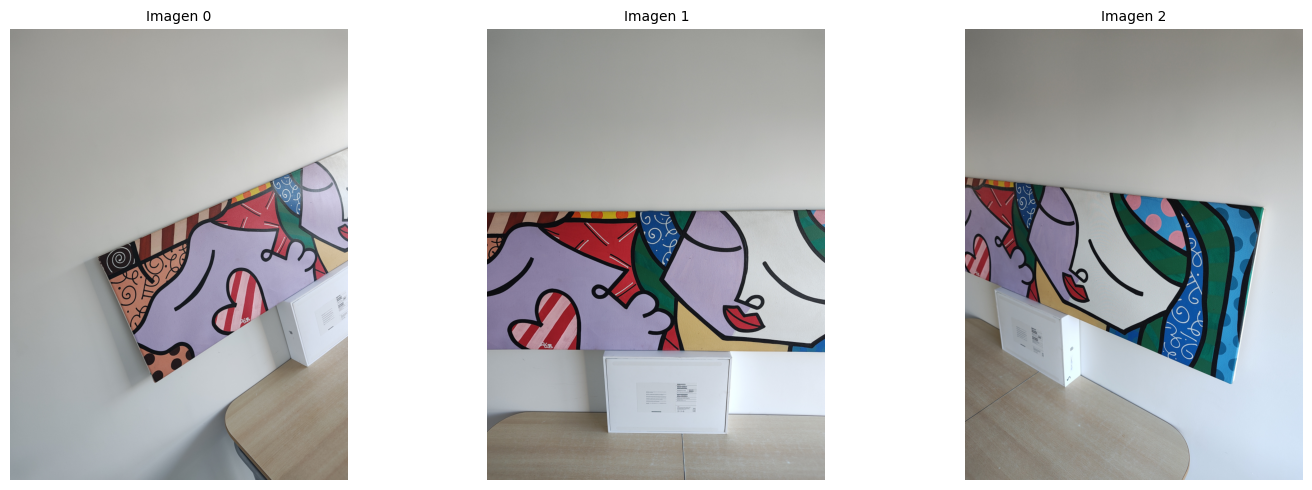

In [32]:
img0_cuadro = achicar(cv2.imread(imagenes_cuadro[0]))
img1_cuadro = achicar(cv2.imread(imagenes_cuadro[1]))
img2_cuadro = achicar(cv2.imread(imagenes_cuadro[2]))

show_images([img0_cuadro, img1_cuadro, img2_cuadro], titles=['Imagen 0', 'Imagen 1', 'Imagen 2'], figsize=(15,5))

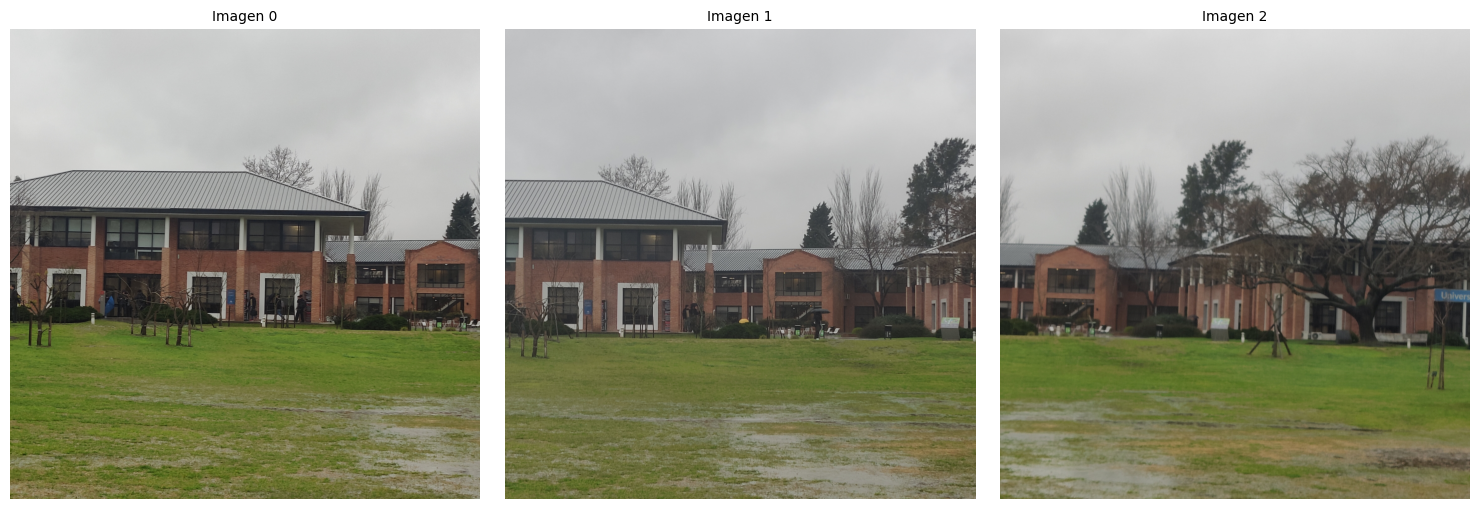

In [33]:
img0_udesa = achicar(cv2.imread(imagenes_udesa[0]))
img1_udesa = achicar(cv2.imread(imagenes_udesa[1]))
img2_udesa = achicar(cv2.imread(imagenes_udesa[2]))

show_images([img0_udesa, img1_udesa, img2_udesa], titles=['Imagen 0', 'Imagen 1', 'Imagen 2'], figsize=(15,5))

In [34]:
# Pasamos las imagenes a escala de grises para que SIFT pueda trabajar con ellas (al hacerlo sobre gradientes de intensidad)
img0_cuadro = cv2.cvtColor(img0_cuadro, cv2.COLOR_BGR2GRAY) 
img1_cuadro = cv2.cvtColor(img1_cuadro, cv2.COLOR_BGR2GRAY) 
img2_cuadro = cv2.cvtColor(img2_cuadro, cv2.COLOR_BGR2GRAY) 

In [35]:
img0_udesa = cv2.cvtColor(img0_udesa, cv2.COLOR_BGR2GRAY) 
img1_udesa = cv2.cvtColor(img1_udesa, cv2.COLOR_BGR2GRAY) 
img2_udesa = cv2.cvtColor(img2_udesa, cv2.COLOR_BGR2GRAY) 

In [36]:
# Creamos el detector de homografias SIFT entre las dos primeras imágenes
sift = cv2.SIFT_create()

In [37]:
# Detectamos keypoints y computamos los descriptores
keypoints0_cuadro, des0 = sift.detectAndCompute(img0_cuadro, None)
keypoints1_cuadro, des1 = sift.detectAndCompute(img1_cuadro, None)
keypoints2_cuadro, des2 = sift.detectAndCompute(img2_cuadro, None)

keypoints0_udesa, des0 = sift.detectAndCompute(img0_udesa, None)
keypoints1_udesa, des1 = sift.detectAndCompute(img1_udesa, None)
keypoints2_udesa, des2 = sift.detectAndCompute(img2_udesa, None)

print('CUADRO')
print(f' largo keypoints0: {len(keypoints0_cuadro)}, largo keypoints1: {len(keypoints1_cuadro)}, largo keypoints2: {len(keypoints2_cuadro)}')
print('UDESA')
print(f' largo keypoints0: {len(keypoints0_udesa)}, largo keypoints1: {len(keypoints1_udesa)}, largo keypoints2: {len(keypoints2_udesa)}')

CUADRO
 largo keypoints0: 481, largo keypoints1: 450, largo keypoints2: 490
UDESA
 largo keypoints0: 3118, largo keypoints1: 3038, largo keypoints2: 2756


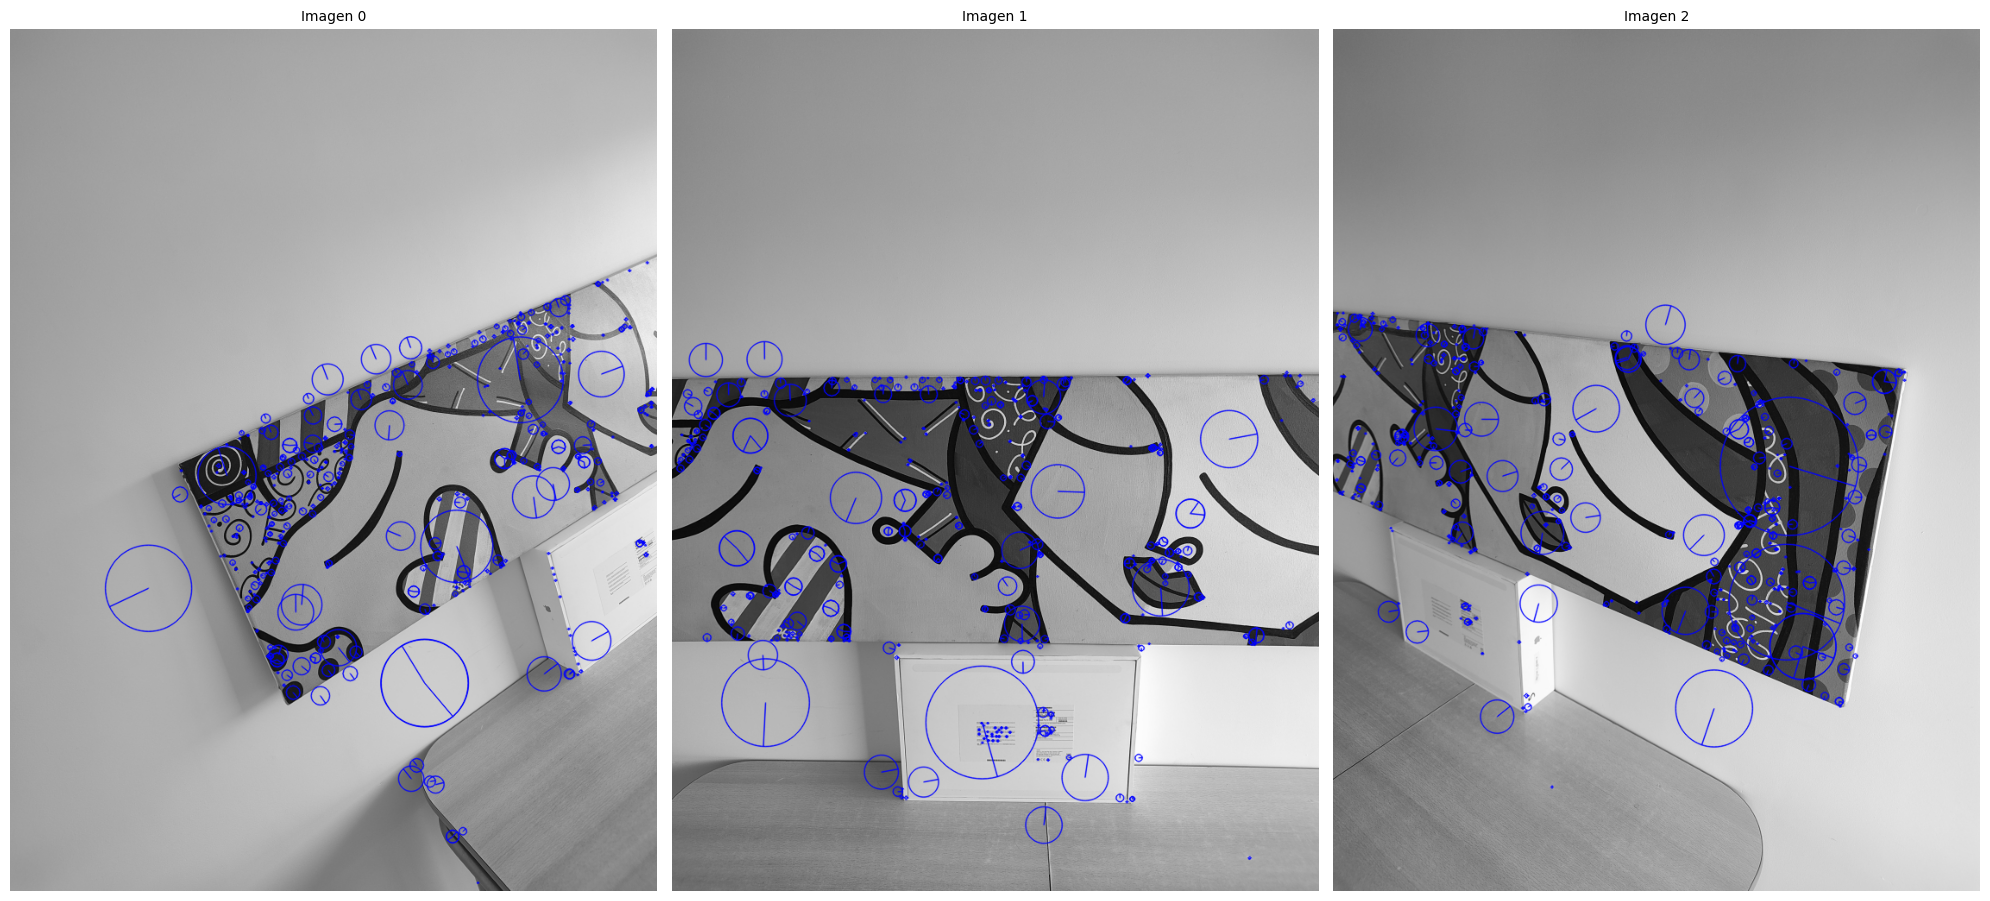

In [38]:
# Visualizamos los keypoints
keypoints_img0_cuadro = cv2.drawKeypoints(img0_cuadro, keypoints0_cuadro, 0, (255, 0, 0), flags = cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
keypoints_img1_cuadro = cv2.drawKeypoints(img1_cuadro, keypoints1_cuadro, 0, (255, 0, 0), flags = cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
keypoints_img2_cuadro = cv2.drawKeypoints(img2_cuadro, keypoints2_cuadro, 0, (255, 0, 0), flags = cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

show_images([keypoints_img0_cuadro, keypoints_img1_cuadro, keypoints_img2_cuadro], titles = ['Imagen 0', 'Imagen 1', 'Imagen 2'], figsize=(20,10))

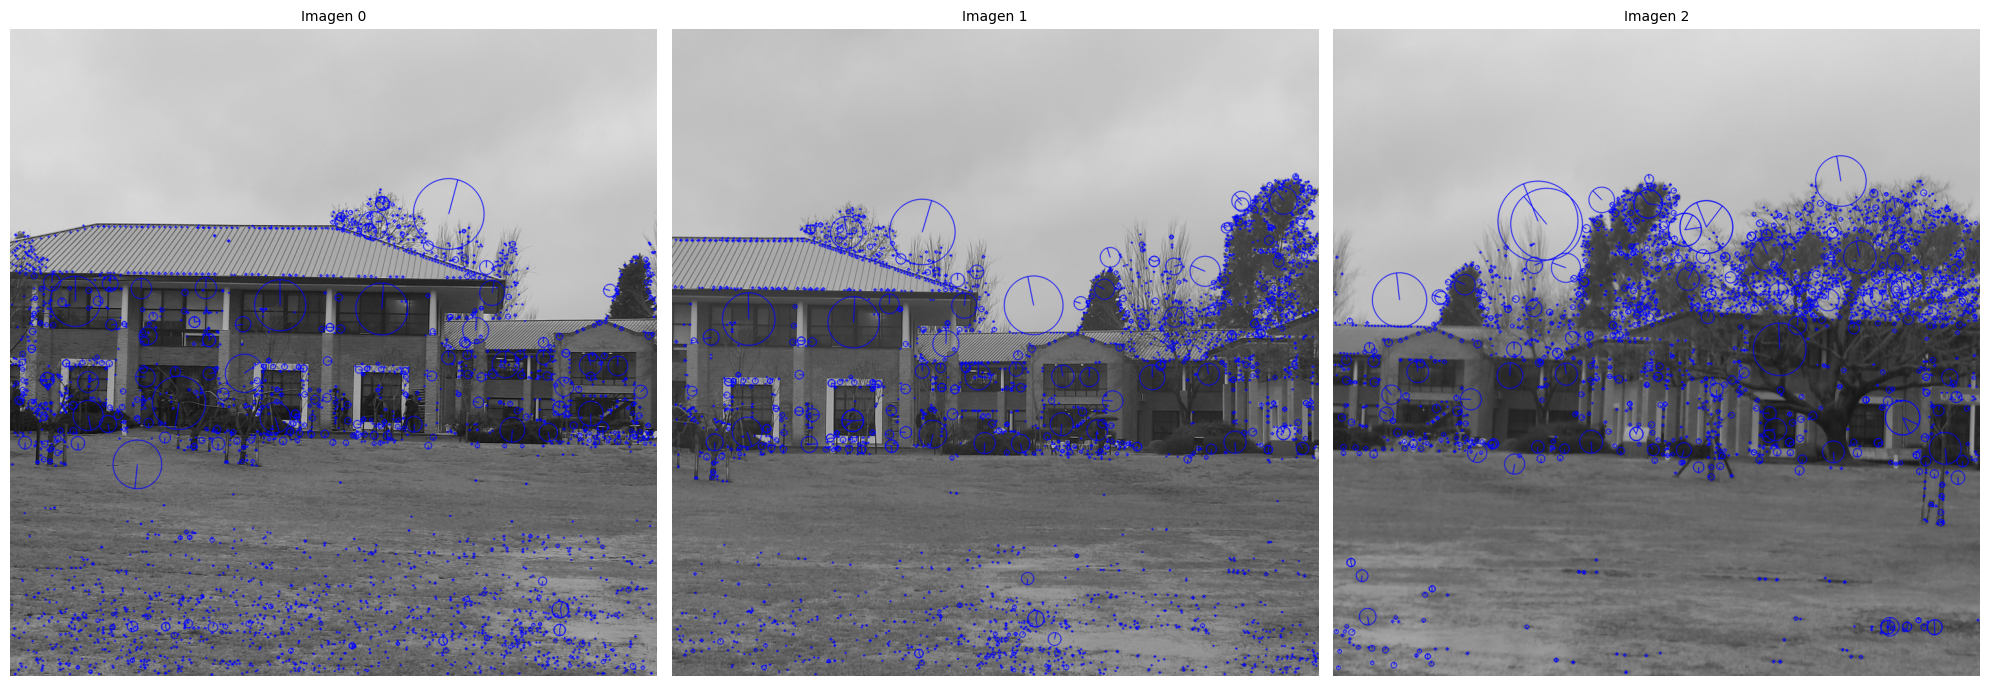

In [39]:
keypoints_img0_udesa = cv2.drawKeypoints(img0_udesa, keypoints0_udesa, 0, (255, 0, 0), flags = cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
keypoints_img1_udesa = cv2.drawKeypoints(img1_udesa, keypoints1_udesa, 0, (255, 0, 0), flags = cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
keypoints_img2_udesa = cv2.drawKeypoints(img2_udesa, keypoints2_udesa, 0, (255, 0, 0), flags = cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

show_images([keypoints_img0_udesa, keypoints_img1_udesa, keypoints_img2_udesa], titles = ['Imagen 0', 'Imagen 1', 'Imagen 2'], figsize=(20,10))

### *Supresión de No-Máxima Adaptativa*

In [40]:
n_deseados = 200

keypoints0_cuadro_anms, des0_anms = aplicar_anms(keypoints0_cuadro, des0, n_deseados)
keypoints1_cuadro_anms, des1_anms = aplicar_anms(keypoints1_cuadro, des1, n_deseados)
keypoints2_cuadro_anms, des2_anms = aplicar_anms(keypoints2_cuadro, des2, n_deseados)

print(f'Antes: {len(keypoints0_cuadro)}, Después: {len(keypoints0_cuadro_anms)}')
print(f'Antes: {len(keypoints1_cuadro)}, Después: {len(keypoints1_cuadro_anms)}')
print(f'Antes: {len(keypoints2_cuadro)}, Después: {len(keypoints2_cuadro_anms)}')

Antes: 481, Después: 200
Antes: 450, Después: 200
Antes: 490, Después: 200


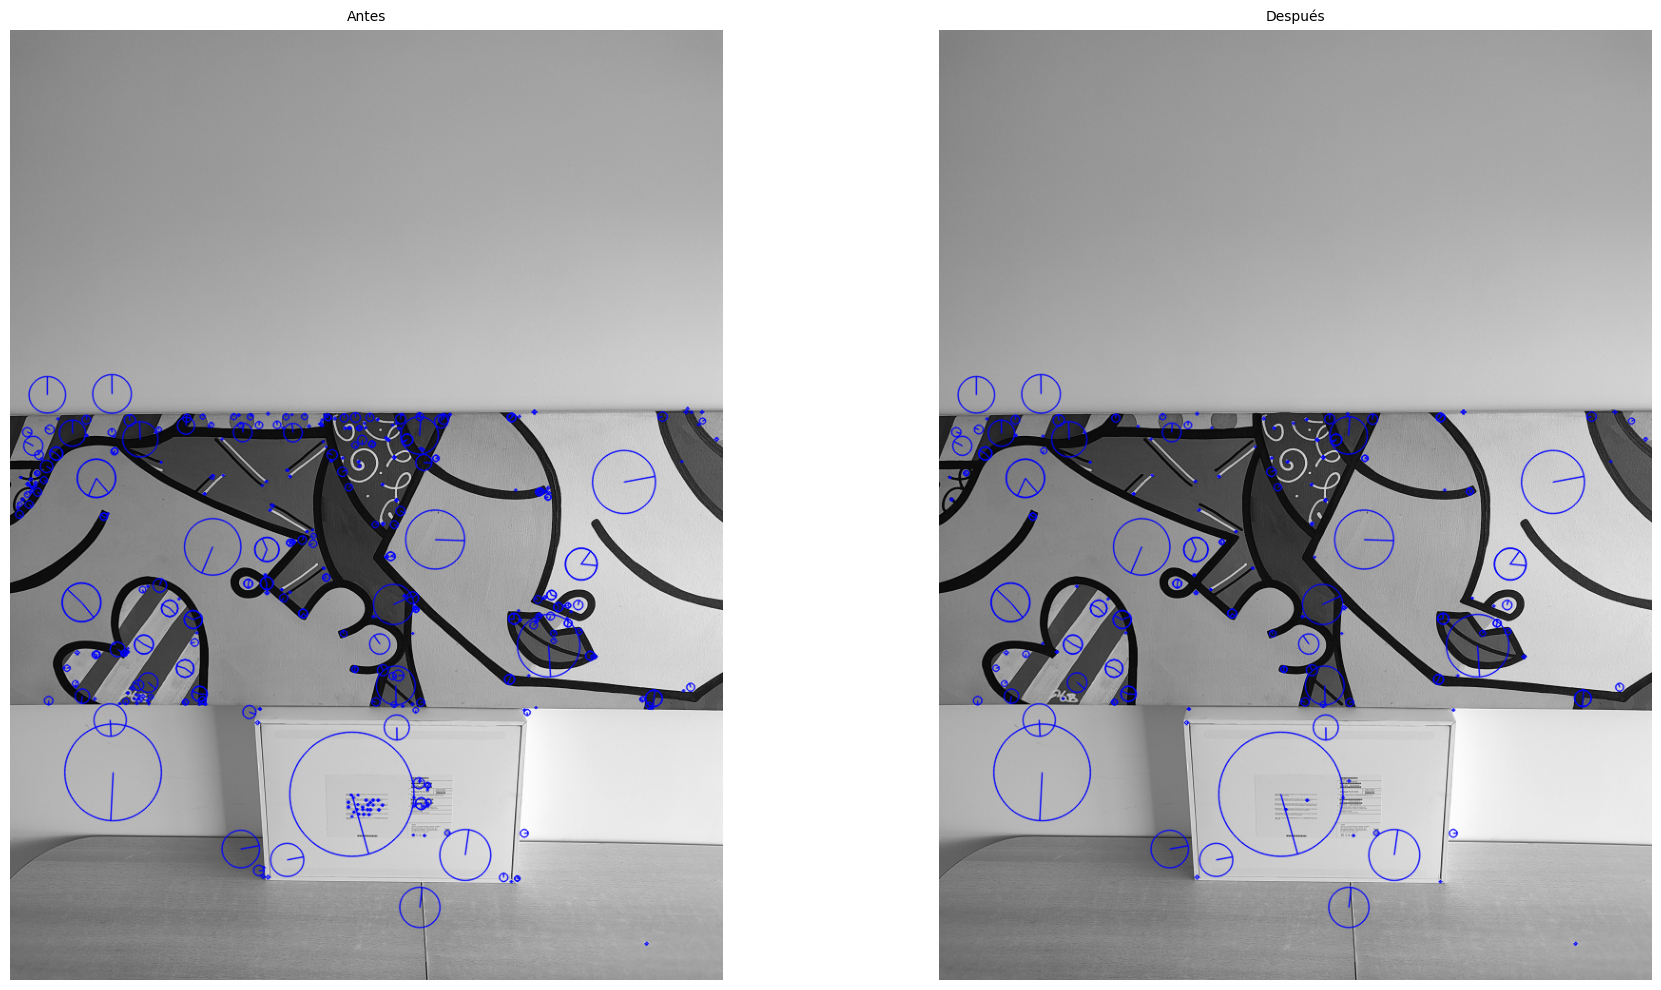

In [ ]:
imagen1_cuadro_antes = cv2.drawKeypoints(img1_cuadro, keypoints1_cuadro, 0, (255, 0, 0), flags = cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
imagen1_cuadro_despues = cv2.drawKeypoints(img1_cuadro, keypoints1_cuadro_anms, 0, (255, 0, 0), flags = cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

show_images([imagen1_cuadro_antes, imagen1_cuadro_despues], titles = ['Antes', 'Después'], figsize=(20,10))

In [42]:
n_deseados_udesa = 500 

keypoints0_udesa_anms, des0_anms = aplicar_anms(keypoints0_udesa, des0, n_deseados_udesa)
keypoints1_udesa_anms, des1_anms = aplicar_anms(keypoints1_udesa, des1, n_deseados_udesa)
keypoints2_udesa_anms, des2_anms = aplicar_anms(keypoints2_udesa, des2, n_deseados_udesa)

print(f'Antes: {len(keypoints0_udesa)}, Después: {len(keypoints0_udesa_anms)}')
print(f'Antes: {len(keypoints1_udesa)}, Después: {len(keypoints1_udesa_anms)}')
print(f'Antes: {len(keypoints2_udesa)}, Después: {len(keypoints2_udesa_anms)}')

Antes: 3118, Después: 500
Antes: 3038, Después: 500
Antes: 2756, Después: 500


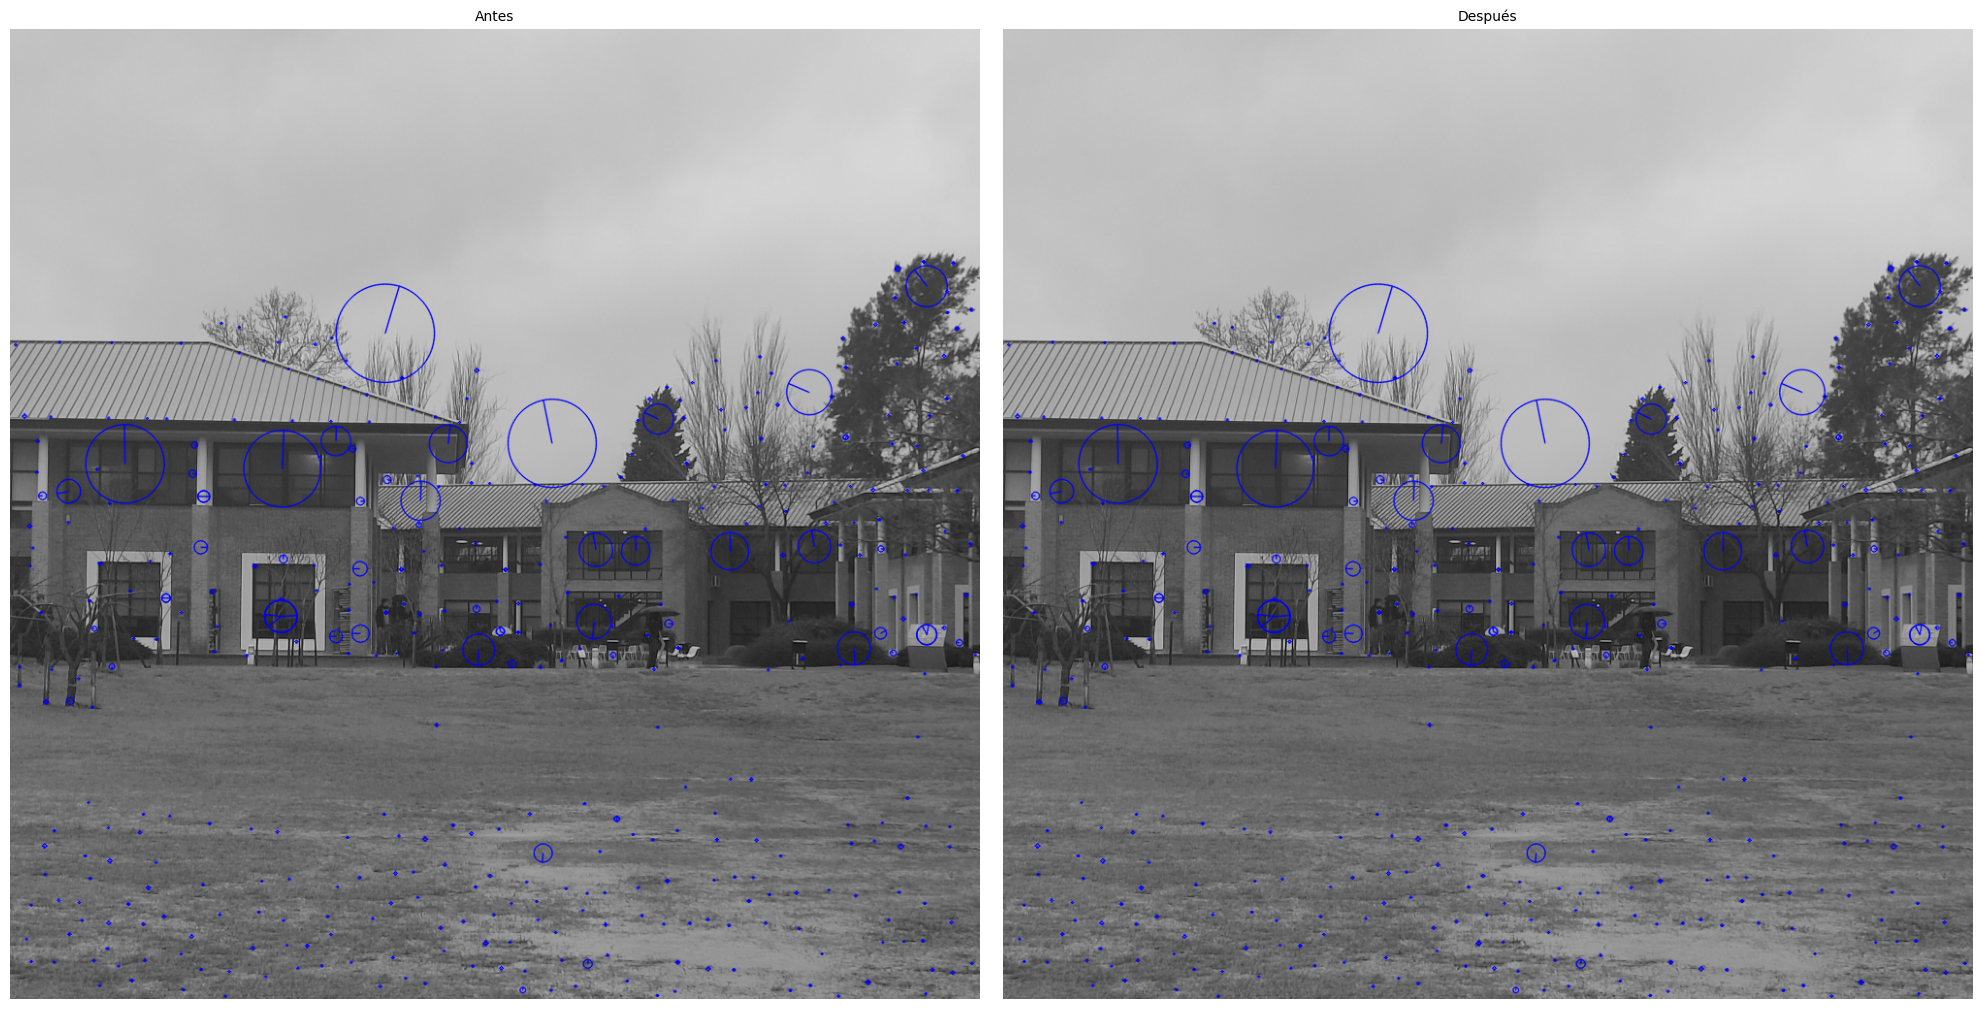

In [43]:
imagen1_udesa_antes = cv2.drawKeypoints(img1_udesa, keypoints1_udesa_anms, 0, (255, 0, 0), flags = cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
imagen1_udesa_despues = cv2.drawKeypoints(img1_udesa, keypoints1_udesa_anms, 0, (255, 0, 0), flags = cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

show_images([imagen1_udesa_antes, imagen1_udesa_despues], titles = ['Antes', 'Después'], figsize=(20,10))